In [1]:
%load_ext autoreload
%autoreload 2

from datasets import load_dataset
from dotenv import load_dotenv
load_dotenv()

import sys
sys.path.append("../..")
from src.utils.vlm_utils import display_image, do_image_analysis, check_screenshot_validity, do_ocr

dataset = load_dataset("Vokturz/sourceforge-app-screenshots")

/home/pudu/codegpt/codegpt-swe-bench/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Filter: 100%|██████████████████████████████████████████████████████████████████████████| 1393/1393 [00:04<00:00, 282.41 examples/s]


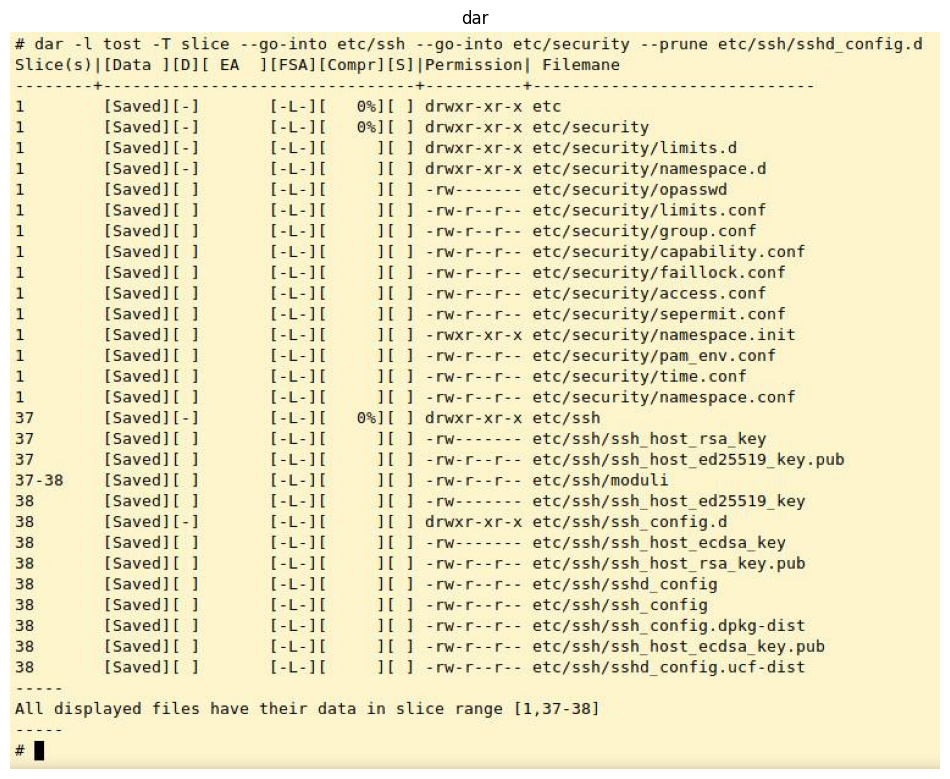

{'slug': 'dar',
 'url': 'https://sourceforge.net/p/dar/',
 'title': 'DAR - Disk ARchive',
 'registration_date': datetime.datetime(2002, 10, 25, 0, 0),
 'description': "DAR is a command-line backup and archiving tool that uses selective compression (not compressing already compressed files), strong encryption, may split an archive in different files of given size and provides on-fly hashing, supports differential backup with or without binary delta, ftp and sftp protocols to remote cloud storage\r\n\r\nArchive internal's catalog, allows very quick restoration even a single file from a huge, eventually sliced, compressed, encrypted archive eventually located on a remote cloud storage, by only reading/fetching the necessary data to perform the operation.\r\n\r\nDar saves *all* UNIX inode types, takes care of hard links, sparse files as well as  Extended Attributes (MacOS X file forks, Linux ACL, SELinux tags, user attributes) and some  Filesystem Specific Attributes (Linux ext2/3/4, Mac O

In [6]:
example = dataset['train'][800]
example = dataset['train'].filter(lambda x: x['slug'] == 'dar')[0]
display_image(example)
example

In [7]:
check_screenshot_validity(example, True)

The screenshot shows a terminal output of a `dar` command being executed, listing files and their attributes (permissions, slices, etc.) — consistent with DAR’s functionality as a command-line archiving tool. The interface is text-based, which matches DAR’s CLI nature. No unrelated apps, mobile UI, or documentation elements are present.

VALID


True

In [8]:
image_analysis = do_image_analysis(example, True)

<description>The screenshot displays a terminal interface running the "DAR - Disk ARchive" application. The command executed is `dar -l tost -T slice --go-into etc/ssh --go-into etc/security --prune etc/ssh/sshd_config.d`, which lists archive contents with slicing and filtering options. The output shows a table-like structure with columns for Slice(s), Data [ID], EA, [FSA], [Compr], [S], Permission, and Filename. It lists files under directories such as /etc/security and /etc/ssh, including configuration files like sshd_config, ssh_host_rsa_key, and others. Permissions and file types are displayed in standard Unix format (e.g., drwxr-xr-x, -rw-r--r--). At the bottom, a note indicates: “All displayed files have their data in slice range [1,37-38]”. A shell prompt (`#`) is visible at the end.</description>
<keywords>DAR, Disk ARchive, terminal, command line, dar command, archive listing, etc/ssh, etc/security, file permissions, slice</keywords>
<category>terminal</category>


In [9]:
from IPython.display import display, Markdown
markdown = do_ocr(example, image_analysis)
display(Markdown(markdown))

```bash
# dar -l tost -T slice --go-into etc/ssh --go-into etc/security --prune etc/ssh/sshd_config.d
Slice(s)|[Data][ID]| EA |[FSA]|[Compr][S]|Permission|Filename
--------|----------|----|-----|----------|----------|--------
1        |[Saved]   |[-L-]|     |0%       |drwxr-xr-x|etc/security
1        |[Saved]   |[-L-]|     |         |drwxr-xr-x|etc/security/limits.d
1        |[Saved]   |[-L-]|     |         |drwxr-xr-x|etc/security/namespace.d
1        |[Saved]   |[-L-]|     |         |-rw-------|etc/security/opasswd
1        |[Saved]   |[-L-]|     |         |-rw-r--r--|etc/security/limits.conf
1        |[Saved]   |[-L-]|     |         |-rw-r--r--|etc/security/group.conf
1        |[Saved]   |[-L-]|     |         |-rw-r--r--|etc/security/capability.conf
1        |[Saved]   |[-L-]|     |         |-rw-r--r--|etc/security/faillock.conf
1        |[Saved]   |[-L-]|     |         |-rw-r--r--|etc/security/access.conf
1        |[Saved]   |[-L-]|     |         |-rw-r--r--|etc/security/sepermit.conf
1        |[Saved]   |[-L-]|     |         |-rwxr-xr-x|etc/security/namespace.init
1        |[Saved]   |[-L-]|     |         |-rw-r--r--|etc/security/pam_env.conf
1        |[Saved]   |[-L-]|     |         |-rw-r--r--|etc/security/time.conf
1        |[Saved]   |[-L-]|     |         |-rw-r--r--|etc/security/namespace.conf
37       |[Saved]   |[-L-]|     |0%       |drwxr-xr-x|etc/ssh
37       |[Saved]   |[-L-]|     |         |-rw-------|etc/ssh/ssh_host_rsa_key
37-38    |[Saved]   |[-L-]|     |         |-rw-r--r--|etc/ssh/ssh_host_ed25519_key.pub
38       |[Saved]   |[-L-]|     |         |-rw-------|etc/ssh/ssh_host_ed25519_key
38       |[Saved]   |[-L-]|     |         |drwxr-xr-x|etc/ssh/sshd_config.d
38       |[Saved]   |[-L-]|     |         |-rw-------|etc/ssh/ssh_host_ecdsa_key
38       |[Saved]   |[-L-]|     |         |-rw-r--r--|etc/ssh/ssh_host_rsa_key.pub
38       |[Saved]   |[-L-]|     |         |-rw-r--r--|etc/ssh/sshd_config
38       |[Saved]   |[-L-]|     |         |-rw-r--r--|etc/ssh/ssh_config
38       |[Saved]   |[-L-]|     |         |-rw-r--r--|etc/ssh/ssh_config.dpkg-dist
38       |[Saved]   |[-L-]|     |         |-rw-r--r--|etc/ssh/ssh_host_ecdsa_key.pub
38       |[Saved]   |[-L-]|     |         |-rw-r--r--|etc/ssh/sshd_config.ucf-dist
-----
All displayed files have their data in slice range [1,37-38]
#
```